# 09 — Figures

Generate all figures for the paper.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import ast
import pyarrow.parquet as pq
from pathlib import Path

from shadow.utils.plots import apply_style, GOV, OPP, ACCENT, IS_CLR, OOS_CLR, SHADE

apply_style()

DATA = Path("../data/interim")
FIG  = Path("../paper/figures")
FIG.mkdir(exist_ok=True)

# Standard figure sizes (single-column ~4.8", matching 6.5" page width at 85%)
SINGLE = (4.8, 4.0)
WIDE   = (6.5, 4.0)
TALL   = (4.8, 5.5)

## Figure E2 — Burnout Convergence (Stage 1 training)

Shows spatial-lag convergence during training for all 25 imputation draws.
Full per-iteration trajectories available for 13 draws; summary (n_iters, final_delta) for 12.

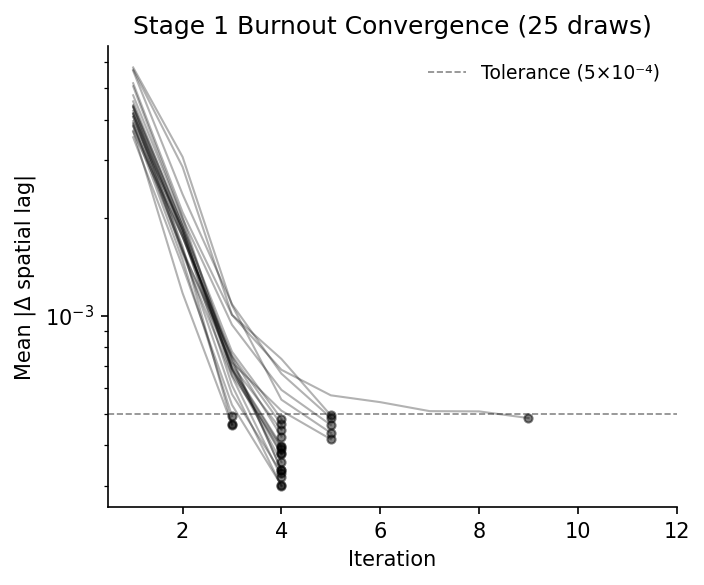

Saved to ../paper/figures/fig-fp-convergence.pdf


In [2]:
# ── Figure E2: Burnout convergence ──────────────────────────────

files = sorted(DATA.glob("sl_spat_conv_*.parquet"))
curves = []

for f in files:
    schema = pq.read_schema(f)
    cols = schema.names
    read_cols = ["cy", "ud"] + [c for c in ["n_iters", "final_delta", "deltas"] if c in cols]
    df = pd.read_parquet(f, columns=read_cols)
    cy, ud = int(df["cy"].iloc[0]), int(df["ud"].iloc[0])

    if "deltas" in cols:
        deltas = ast.literal_eval(str(df["deltas"].iloc[0]))
        curves.append({"cy": cy, "ud": ud, "deltas": deltas})
    else:
        n = int(df["n_iters"].iloc[0])
        fd = float(df["final_delta"].iloc[0])
        curves.append({"cy": cy, "ud": ud, "deltas": [fd], "n_iters_only": n})

fig, ax = plt.subplots(figsize=SINGLE)

for c in curves:
    d = c["deltas"]
    if "n_iters_only" in c:
        ax.scatter(c["n_iters_only"], d[-1], color=GOV, s=20, alpha=0.5, zorder=5)
    else:
        iters = list(range(1, len(d) + 1))
        ax.plot(iters, d, color=GOV, alpha=0.3, linewidth=1, zorder=3)
        ax.scatter(iters[-1], d[-1], color=GOV, s=15, alpha=0.5, zorder=5)

# Reference line at convergence tolerance
ax.axhline(5e-4, color=OPP, linestyle="--", linewidth=0.8, label="Tolerance (5×10⁻⁴)")

ax.set_yscale("log")
ax.set_xlabel("Iteration")
ax.set_ylabel("Mean |Δ spatial lag|")
ax.set_title("Stage 1 Burnout Convergence (25 draws)")
ax.legend(frameon=False, fontsize=9)
ax.set_xlim(0.5, 12)

fig.tight_layout()
fig.savefig(FIG / "fig-fp-convergence.pdf", bbox_inches="tight")
plt.show()
print(f"Saved to {FIG / 'fig-fp-convergence.pdf'}")

## Figure E1 — Reliability Diagrams (Stage 1 calibration)

Three-panel calibration plot: observed frequency vs. mean predicted probability
for each outcome class (none, government-biased, opposition-biased).
Pooled across all 25 imputation draws.

Pooled OOF: 643200 rows (25 draws)


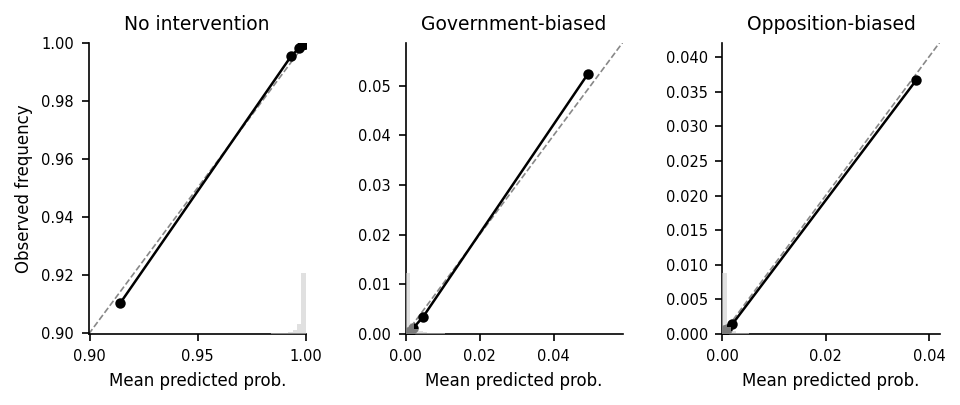

Saved to ../paper/figures/fig-sl-calibration.pdf


In [3]:
# ── Figure E1: Reliability diagrams ─────────────────────────────

from sklearn.calibration import calibration_curve

# Load and pool all 25 OOF prediction files
oof_files = sorted(DATA.glob("sl_oof_*.parquet"))
assert len(oof_files) == 25, f"Expected 25, found {len(oof_files)}"
oof = pd.concat([pd.read_parquet(f) for f in oof_files], ignore_index=True)
print(f"Pooled OOF: {len(oof)} rows ({len(oof_files)} draws)")

CLASSES = {
    0: ("No intervention", "p_none"),
    1: ("Government-biased", "p_gov"),
    2: ("Opposition-biased", "p_opp"),
}

fig, axes = plt.subplots(1, 3, figsize=(6.5, 2.8))

for ax, (k, (label, pcol)) in zip(axes, CLASSES.items()):
    y_bin = (oof["intervention"] == k).astype(int).values
    p = oof[pcol].values

    # Use quantile bins for robust binning with rare events
    frac_pos, mean_pred = calibration_curve(y_bin, p, n_bins=10, strategy="quantile")

    # Calibration curve
    ax.plot(mean_pred, frac_pos, "o-", color=GOV, markersize=4, linewidth=1.2,
            zorder=5)

    # Zoom to where data lives, with small padding
    lo = min(mean_pred.min(), frac_pos.min())
    hi = max(mean_pred.max(), frac_pos.max())
    pad = (hi - lo) * 0.12
    lo = max(0, lo - pad)
    hi = min(1, hi + pad)
    ax.set_xlim(lo, hi)
    ax.set_ylim(lo, hi)

    # Perfect-calibration diagonal (within zoomed range)
    ax.plot([lo, hi], [lo, hi], "--", color=OPP, linewidth=0.8, zorder=1)

    # Histogram inset
    ax_hist = ax.inset_axes([0.0, 0.0, 1.0, 0.22])
    ax_hist.hist(p, bins=50, range=(lo, hi), color=SHADE, alpha=0.6,
                 edgecolor="none")
    ax_hist.set_xlim(lo, hi)
    ax_hist.set_xticks([])
    ax_hist.set_yticks([])
    ax_hist.patch.set_alpha(0)
    for spine in ax_hist.spines.values():
        spine.set_visible(False)

    ax.set_title(label, fontsize=9)
    ax.set_xlabel("Mean predicted prob.", fontsize=8)
    ax.tick_params(labelsize=7)

axes[0].set_ylabel("Observed frequency", fontsize=8)

fig.tight_layout(w_pad=1.5)
fig.savefig(FIG / "fig-sl-calibration.pdf", bbox_inches="tight")
plt.show()
print(f"Saved to {FIG / 'fig-sl-calibration.pdf'}")

## Figures gated on nb06

These require all 25 `cy_shadow_*.parquet` and `sl_preds_*.parquet` files.

In [4]:
# ── Helper: load and average cy_shadow across draws ──────────────

def load_cy_shadow():
    """Average shadow measures across all available imputation draws."""
    files = sorted(DATA.glob("cy_shadow_*.parquet"))
    assert len(files) == 25, f"Expected 25 cy_shadow files, found {len(files)}"
    dfs = [pd.read_parquet(f) for f in files]
    avg = pd.concat(dfs).groupby(["ccode", "year"]).mean(numeric_only=True).reset_index()
    return avg


def load_sl_preds():
    """Average per-dyad predictions across all available imputation draws."""
    files = sorted(DATA.glob("sl_preds_*.parquet"))
    assert len(files) == 25, f"Expected 25 sl_preds files, found {len(files)}"
    dfs = [pd.read_parquet(f) for f in files]
    avg = pd.concat(dfs).groupby(["ccode_A", "ccode_B", "year"]).mean(numeric_only=True).reset_index()
    return avg

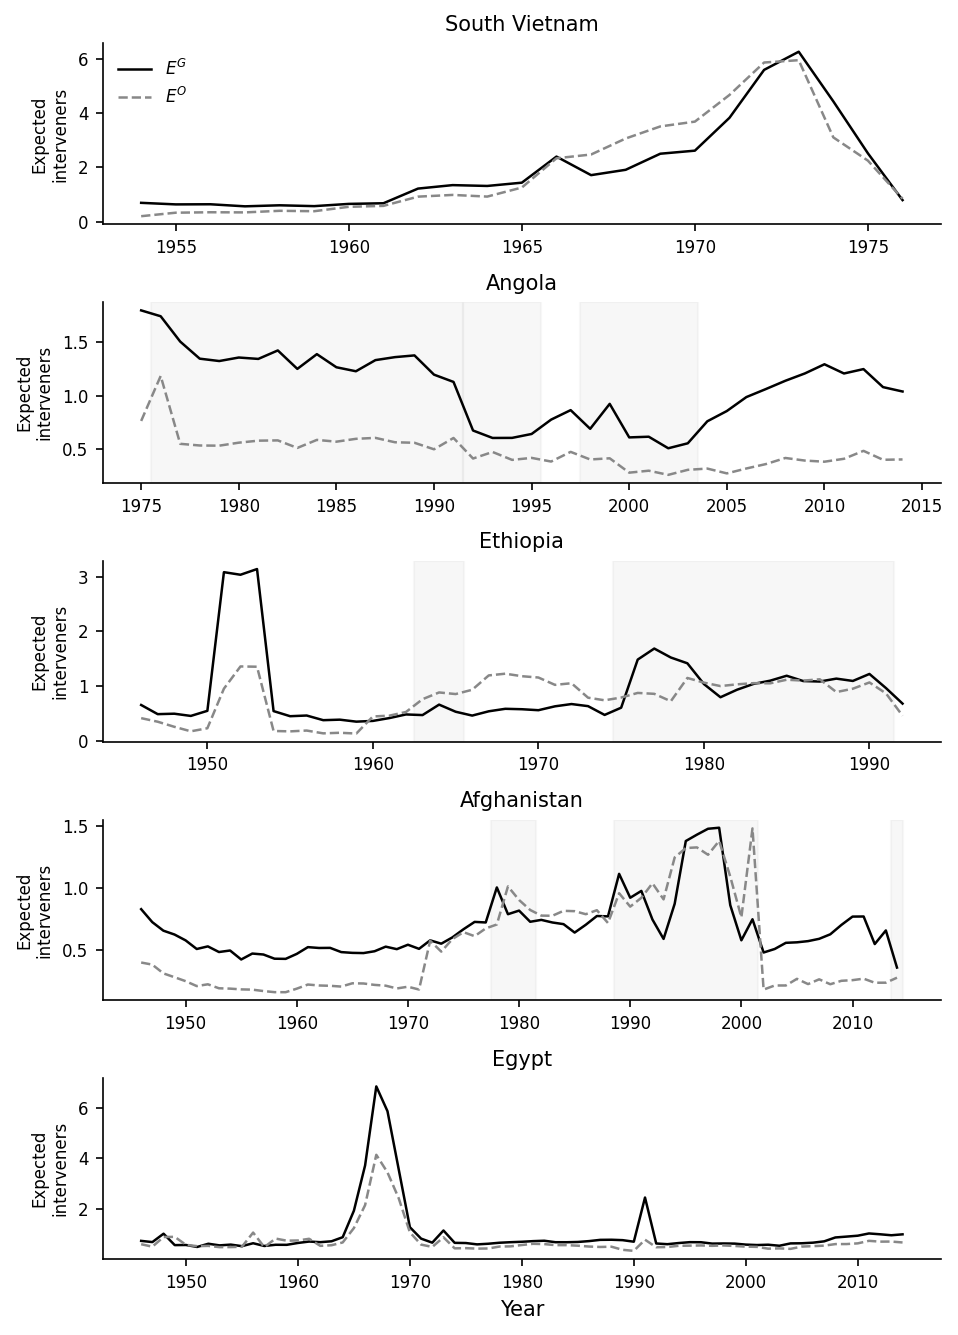

Saved to ../paper/figures/fig-shadow-ts.pdf


In [5]:
# ── Figure 3: Shadow measure time series ───────────────────────

cy = load_cy_shadow()

CASES = {
    "816": "South Vietnam",
    "540": "Angola",
    "530": "Ethiopia",
    "700": "Afghanistan",
    "651": "Egypt",
}

# War years (onset + prior_war from COW Intra-State Wars v5.1)
WAR_SPANS = {
    "540": [(1976, 1991), (1992, 1995), (1998, 2003)],   # Angola
    "530": [(1963, 1965), (1975, 1991)],                  # Ethiopia
    "700": [(1978, 1981), (1989, 2001), (2014, 2014)],    # Afghanistan
}

fig, axes = plt.subplots(len(CASES), 1, figsize=(6.5, 1.8 * len(CASES)),
                         sharex=False)

for ax, (ccode, name) in zip(axes, CASES.items()):
    sub = cy[cy["ccode"] == ccode].sort_values("year")

    # Shade war years
    if ccode in WAR_SPANS:
        for start, end in WAR_SPANS[ccode]:
            ax.axvspan(start - 0.5, end + 0.5, alpha=0.15, color=SHADE,
                       zorder=0)

    ax.plot(sub["year"], sub["E_gov"], label="$E^G$", color=GOV, linewidth=1.2,
            linestyle="-")
    ax.plot(sub["year"], sub["E_opp"], label="$E^O$", color=OPP, linewidth=1.2,
            linestyle="--")
    ax.set_ylabel("Expected\ninterveners", fontsize=8)
    ax.set_title(name, fontsize=10)
    ax.tick_params(labelsize=8)
    if ccode == "816":  # Only legend on first panel
        ax.legend(frameon=False, fontsize=8, loc="upper left")

axes[-1].set_xlabel("Year")
fig.tight_layout(h_pad=0.8)
fig.savefig(FIG / "fig-shadow-ts.pdf", bbox_inches="tight")
plt.show()
print(f"Saved to {FIG / 'fig-shadow-ts.pdf'}")

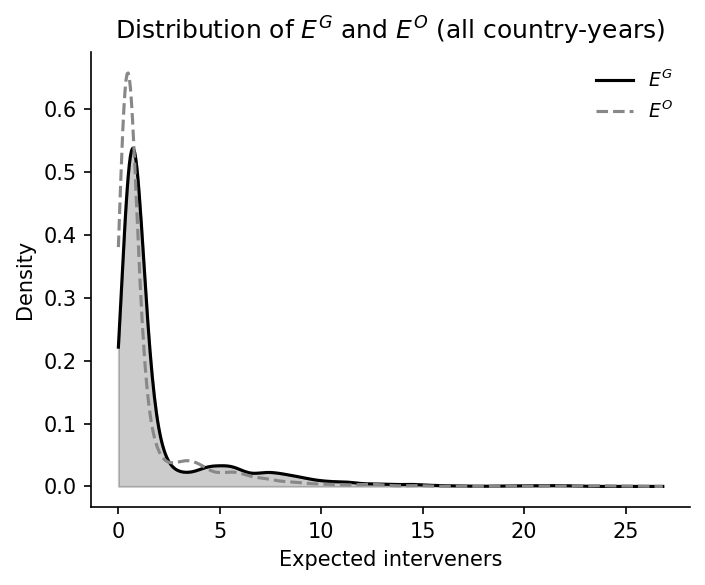

Saved to ../paper/figures/fig-shadow-kde.pdf


In [6]:
# ── Figure 4: Shadow KDE ───────────────────────────────────────

from scipy.stats import gaussian_kde

cy = load_cy_shadow()

fig, ax = plt.subplots(figsize=SINGLE)

x_grid = np.linspace(0, cy[["E_gov", "E_opp"]].max().max() * 1.05, 500)

for col, label, color, ls in [("E_gov", "$E^G$", GOV, "-"),
                               ("E_opp", "$E^O$", OPP, "--")]:
    vals = cy[col].dropna().values
    kde = gaussian_kde(vals, bw_method=0.15)
    ax.plot(x_grid, kde(x_grid), color=color, linestyle=ls, linewidth=1.5,
            label=label)

ax.fill_between(x_grid, gaussian_kde(cy["E_gov"].dropna().values, bw_method=0.15)(x_grid),
                alpha=0.2, color=GOV)

ax.set_xlabel("Expected interveners")
ax.set_ylabel("Density")
ax.set_title("Distribution of $E^G$ and $E^O$ (all country-years)")
ax.legend(frameon=False, fontsize=9)

fig.tight_layout()
fig.savefig(FIG / "fig-shadow-kde.pdf", bbox_inches="tight")
plt.show()
print(f"Saved to {FIG / 'fig-shadow-kde.pdf'}")

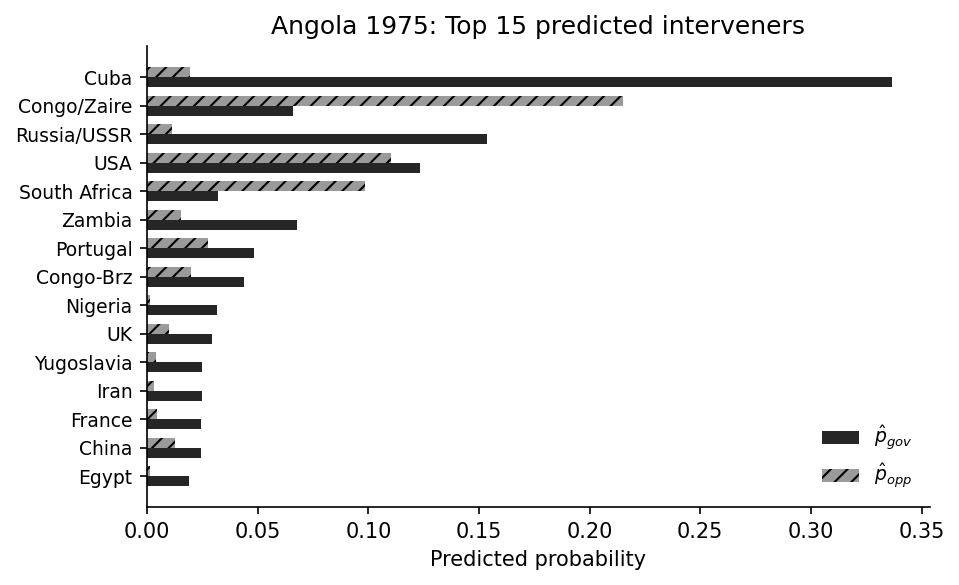

Saved to ../paper/figures/fig-shadow-refinement.pdf


In [7]:
# ── Figure 2: Angola 1975 spike plot (refinement) ──────────────

preds = load_sl_preds()

# Angola ccode_A = 540, year = 1975
angola75 = preds[(preds["ccode_A"] == "540") & (preds["year"] == 1975)].copy()
angola75 = angola75.sort_values("p_gov", ascending=False)

# Country name lookup (COW ccodes → names for top interveners)
COW_NAMES = {
    "002": "USA", "020": "Canada", "040": "Cuba", "041": "Haiti",
    "042": "Dominican Rep.", "070": "Mexico", "090": "Guatemala",
    "091": "Honduras", "092": "El Salvador", "093": "Nicaragua",
    "094": "Costa Rica", "095": "Panama", "100": "Colombia",
    "101": "Venezuela", "130": "Ecuador", "135": "Peru",
    "140": "Brazil", "145": "Bolivia", "150": "Paraguay",
    "155": "Chile", "160": "Argentina", "165": "Uruguay",
    "200": "UK", "205": "Ireland", "210": "Netherlands",
    "211": "Belgium", "212": "Luxembourg", "220": "France",
    "225": "Switzerland", "230": "Spain", "235": "Portugal",
    "255": "W. Germany", "260": "Germany", "265": "E. Germany",
    "290": "Poland", "305": "Austria", "310": "Hungary",
    "315": "Czechoslovakia", "316": "Czech Rep.", "317": "Slovakia",
    "325": "Italy", "338": "Malta", "339": "Albania",
    "341": "Montenegro", "343": "Macedonia", "344": "Croatia",
    "345": "Yugoslavia", "346": "Bosnia", "349": "Slovenia",
    "350": "Greece", "352": "Cyprus", "355": "Bulgaria",
    "359": "Moldova", "360": "Romania", "364": "Russia/USSR",
    "365": "Russia", "366": "Estonia", "367": "Latvia",
    "368": "Lithuania", "369": "Ukraine", "370": "Belarus",
    "371": "Armenia", "372": "Georgia", "373": "Azerbaijan",
    "375": "Finland", "380": "Sweden", "385": "Norway",
    "390": "Denmark", "395": "Iceland",
    "432": "Mali", "433": "Senegal", "434": "Benin",
    "435": "Mauritania", "436": "Niger", "437": "Ivory Coast",
    "438": "Guinea", "439": "Burkina Faso", "450": "Liberia",
    "451": "Sierra Leone", "452": "Ghana", "461": "Togo",
    "471": "Cameroon", "475": "Nigeria", "481": "Gabon",
    "482": "C.A.R.", "483": "Chad", "484": "Congo-Brz",
    "490": "Congo/Zaire", "500": "Uganda", "501": "Kenya",
    "510": "Tanzania", "516": "Burundi", "517": "Rwanda",
    "520": "Somalia", "530": "Ethiopia", "540": "Angola",
    "541": "Mozambique", "551": "Zambia", "552": "Zimbabwe",
    "553": "Malawi", "560": "South Africa", "570": "Lesotho",
    "571": "Botswana", "572": "Swaziland", "580": "Madagascar",
    "581": "Comoros", "590": "Mauritius",
    "600": "Morocco", "615": "Algeria", "616": "Tunisia",
    "620": "Libya", "625": "Sudan", "626": "South Sudan",
    "630": "Iran", "640": "Turkey", "645": "Iraq",
    "651": "Egypt", "652": "Syria", "660": "Lebanon",
    "663": "Jordan", "666": "Israel", "670": "Saudi Arabia",
    "678": "Yemen", "679": "Yemen (N)", "680": "Yemen (S)",
    "690": "Kuwait", "692": "Bahrain", "694": "Qatar", "696": "UAE",
    "700": "Afghanistan", "710": "China", "712": "Mongolia",
    "713": "Taiwan", "731": "North Korea", "732": "South Korea",
    "740": "Japan", "750": "India", "770": "Pakistan",
    "771": "Bangladesh", "775": "Myanmar", "780": "Sri Lanka",
    "790": "Nepal", "800": "Thailand", "811": "Cambodia",
    "812": "Laos", "816": "South Vietnam", "817": "Vietnam",
    "820": "Malaysia", "830": "Singapore", "840": "Philippines",
    "850": "Indonesia", "900": "Australia",
    "910": "Papua New Guinea", "920": "New Zealand",
    "940": "Solomon Islands", "950": "Fiji",
}

angola75["name"] = angola75["ccode_B"].map(COW_NAMES).fillna(angola75["ccode_B"])

# Show top 15 by max(p_gov, p_opp)
angola75["p_max"] = angola75[["p_gov", "p_opp"]].max(axis=1)
top = angola75.nlargest(15, "p_max")

fig, ax = plt.subplots(figsize=WIDE)
y = np.arange(len(top))
h = 0.35
ax.barh(y + h/2, top["p_gov"], height=h, label="$\\hat{p}_{gov}$",
        color=GOV, alpha=0.85)
ax.barh(y - h/2, top["p_opp"], height=h, label="$\\hat{p}_{opp}$",
        color=OPP, alpha=0.85, hatch="///")
ax.set_yticks(y)
ax.set_yticklabels(top["name"], fontsize=9)
ax.set_xlabel("Predicted probability")
ax.set_title("Angola 1975: Top 15 predicted interveners")
ax.legend(frameon=False, fontsize=9)
ax.invert_yaxis()

fig.tight_layout()
fig.savefig(FIG / "fig-shadow-refinement.pdf", bbox_inches="tight")
plt.show()
print(f"Saved to {FIG / 'fig-shadow-refinement.pdf'}")

## Figures gated on nb07

These require `results/stage2_*.parquet` files from notebook 07.

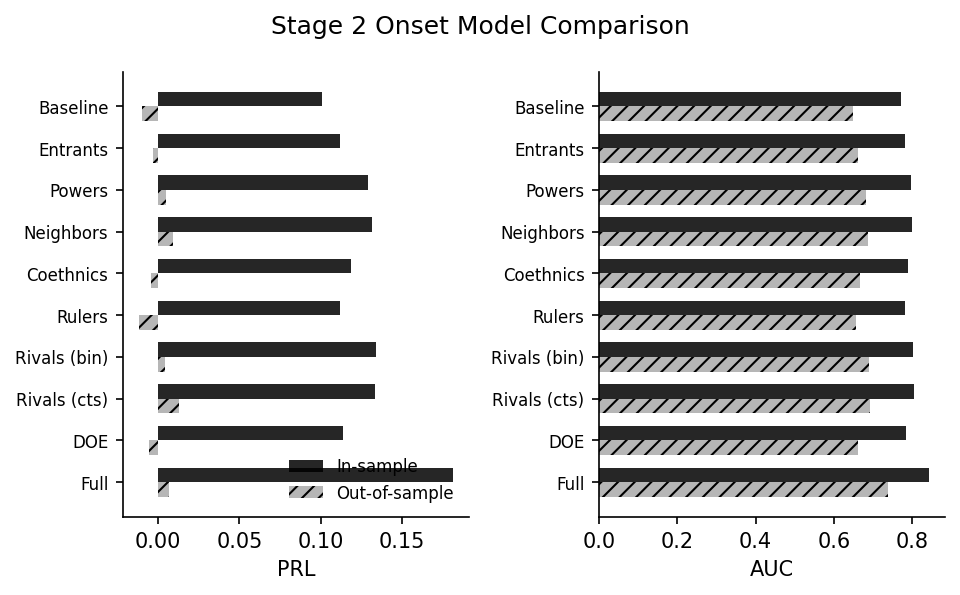

Saved to ../paper/figures/fig-topfit.pdf


In [8]:
# ── Figure 5: Fit comparison (topfit) ──────────────────────────

RESULTS = Path("../results")

fit = pd.read_parquet(RESULTS / "stage2_fit.parquet")

fig, axes = plt.subplots(1, 2, figsize=WIDE)

specs = fit["model"].tolist()
y = np.arange(len(specs))

# Panel 1: PRL
axes[0].barh(y, fit["is_prl"], height=0.35, label="In-sample",
             color=IS_CLR, alpha=0.85)
axes[0].barh(y + 0.35, fit["oos_prl"], height=0.35, label="Out-of-sample",
             color=OOS_CLR, alpha=0.85, hatch="///")
axes[0].set_yticks(y + 0.175)
axes[0].set_yticklabels(specs, fontsize=8)
axes[0].set_xlabel("PRL")
axes[0].legend(frameon=False, fontsize=8)
axes[0].invert_yaxis()

# Panel 2: AUC
axes[1].barh(y, fit["is_auc"], height=0.35, label="In-sample",
             color=IS_CLR, alpha=0.85)
axes[1].barh(y + 0.35, fit["oos_auc"], height=0.35, label="Out-of-sample",
             color=OOS_CLR, alpha=0.85, hatch="///")
axes[1].set_yticks(y + 0.175)
axes[1].set_yticklabels(specs, fontsize=8)
axes[1].set_xlabel("AUC")
axes[1].invert_yaxis()

fig.suptitle("Stage 2 Onset Model Comparison", fontsize=12)
fig.tight_layout()
fig.savefig(FIG / "fig-topfit.pdf", bbox_inches="tight")
plt.show()
print(f"Saved to {FIG / 'fig-topfit.pdf'}")

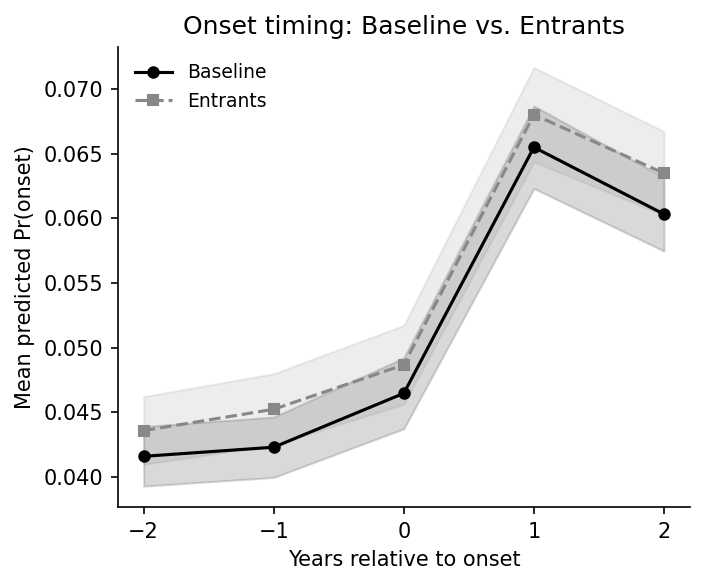

Saved to ../paper/figures/fig-proximate-year.pdf


In [9]:
# ── Figure 6: Proximate-year analysis ──────────────────────────

prox = pd.read_parquet(RESULTS / "stage2_proximate.parquet")

# nb07 saves raw per-event data: (model, ccode, onset_year, dt, p_hat).
# Aggregate to mean ± SE by (model, dt).
fig, ax = plt.subplots(figsize=SINGLE)

styles = {"Baseline": (GOV, "-", "o"), "Entrants": (OPP, "--", "s")}

for spec in ["Baseline", "Entrants"]:
    sub = prox[prox["model"] == spec]
    agg = sub.groupby("dt")["p_hat"].agg(["mean", "sem"]).reset_index()
    agg = agg.sort_values("dt")
    clr, ls, mkr = styles[spec]
    ax.plot(agg["dt"], agg["mean"], marker=mkr, label=spec, linewidth=1.5,
            color=clr, linestyle=ls, markersize=5)
    ax.fill_between(
        agg["dt"],
        agg["mean"] - agg["sem"],
        agg["mean"] + agg["sem"],
        alpha=0.15,
        color=clr,
    )

ax.set_xlabel("Years relative to onset")
ax.set_ylabel("Mean predicted Pr(onset)")
ax.set_title("Onset timing: Baseline vs. Entrants")
ax.legend(frameon=False, fontsize=9)
ax.set_xticks([-2, -1, 0, 1, 2])

fig.tight_layout()
fig.savefig(FIG / "fig-proximate-year.pdf", bbox_inches="tight")
plt.show()
print(f"Saved to {FIG / 'fig-proximate-year.pdf'}")

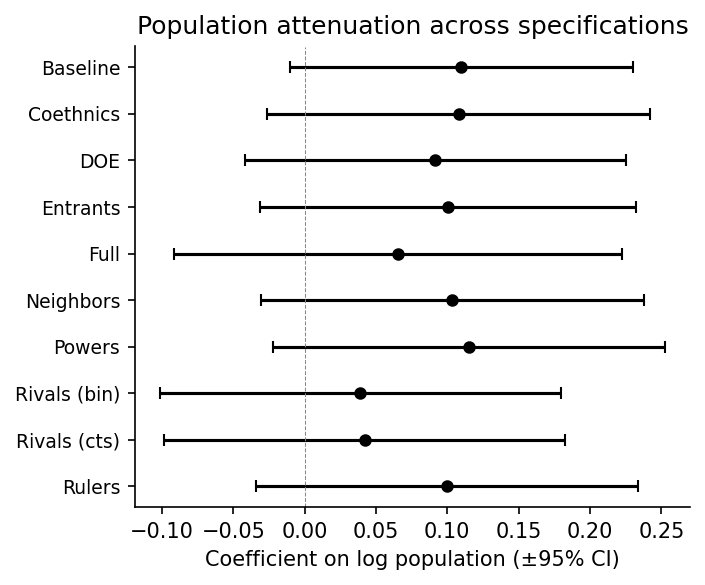

Saved to ../paper/figures/fig-popplot.pdf


In [10]:
# ── Figure 7: Population attenuation ──────────────────────────

coefs = pd.read_parquet(RESULTS / "stage2_coefs.parquet")

# nb07 saves column "model" (not "spec")
lpop = coefs[coefs["variable"] == "lpop_lag"].copy()
lpop = lpop.sort_values("model")

fig, ax = plt.subplots(figsize=SINGLE)

y = np.arange(len(lpop))
ax.errorbar(lpop["coef"], y, xerr=1.96 * lpop["se"], fmt="o", color=GOV,
            capsize=3, markersize=5)
ax.axvline(0, color=OPP, linewidth=0.5, linestyle="--")
ax.set_yticks(y)
ax.set_yticklabels(lpop["model"], fontsize=9)
ax.set_xlabel("Coefficient on log population (±95% CI)")
ax.set_title("Population attenuation across specifications")
ax.invert_yaxis()

fig.tight_layout()
fig.savefig(FIG / "fig-popplot.pdf", bbox_inches="tight")
plt.show()
print(f"Saved to {FIG / 'fig-popplot.pdf'}")

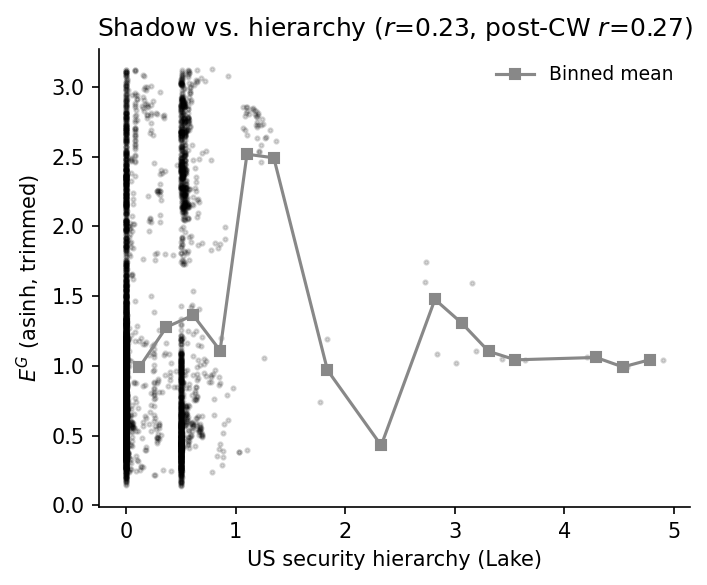

Saved to ../paper/figures/fig-shadow-hierarchy.pdf


In [11]:
# ── Figure E3: Shadow vs Lake hierarchy ────────────────────────

cy = load_cy_shadow()

# Load Lake hierarchy (Cunningham 2016 replication data)
lake = pd.read_stata("../zzz-old_version/Paper-Shadow/R/cunningham.dta",
                     columns=["ccode", "year", "us_SH1995"])
lake["ccode"] = lake["ccode"].astype(int).astype(str)
lake["year"] = lake["year"].astype(int)

merged = cy.merge(lake, on=["ccode", "year"], how="inner")
merged = merged.dropna(subset=["E_gov", "us_SH1995"])

# asinh transform + trim extremes for readability
merged["E_gov_asinh"] = np.arcsinh(merged["E_gov"])
q99 = merged["E_gov_asinh"].quantile(0.99)
plot_df = merged[merged["E_gov_asinh"] <= q99].copy()

corr_all = plot_df["E_gov_asinh"].corr(plot_df["us_SH1995"])
post_cw = plot_df[plot_df["year"] >= 1990]
corr_post = post_cw["E_gov_asinh"].corr(post_cw["us_SH1995"])

fig, ax = plt.subplots(figsize=SINGLE)

ax.scatter(plot_df["us_SH1995"], plot_df["E_gov_asinh"],
           s=4, alpha=0.15, color=GOV, zorder=2)

# Binned means
bins = pd.cut(plot_df["us_SH1995"], bins=20)
binned = plot_df.groupby(bins, observed=True)["E_gov_asinh"].mean()
bin_centers = [(b.left + b.right) / 2 for b in binned.index]
ax.plot(bin_centers, binned.values, "s-", color=OPP, markersize=5,
        linewidth=1.5, zorder=5, label="Binned mean")

ax.set_xlabel("US security hierarchy (Lake)")
ax.set_ylabel("$E^G$ (asinh, trimmed)")
ax.set_title(f"Shadow vs. hierarchy ($r$={corr_all:.2f}, post-CW $r$={corr_post:.2f})")
ax.legend(frameon=False, fontsize=9)

fig.tight_layout()
fig.savefig(FIG / "fig-shadow-hierarchy.pdf", bbox_inches="tight")
plt.show()
print(f"Saved to {FIG / 'fig-shadow-hierarchy.pdf'}")